In [119]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [120]:
id_list = [1, 925, 165, 9, 10, 477, 242, 291]

In [121]:
nr_of_seeds = 10 #nr of seeds in the experiments
index = 291

In [122]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [123]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_1208\2728897559.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_1208\2728897559.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

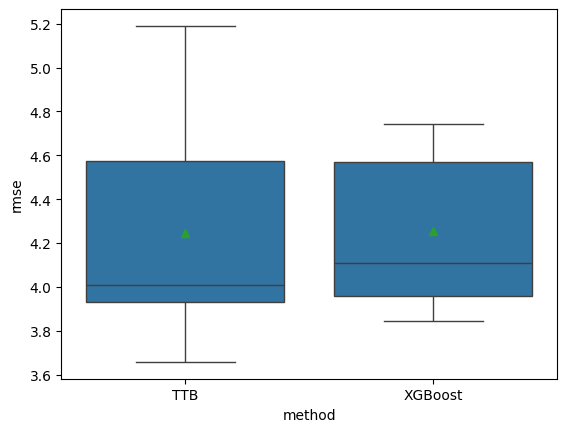

In [124]:


dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [125]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
19,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,850.0,400.0,4.429824,3.765563,5.190418,4.575522,TransferTreeBoost
644,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,858.0,400.0,4.257760,3.650691,4.778838,3.702311,TransferTreeBoost
244,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,853.0,400.0,3.789207,3.013397,3.971804,3.221017,TransferTreeBoost
212,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,852.0,400.0,3.689156,3.061162,3.934220,3.331482,TransferTreeBoost
91,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,851.0,400.0,3.643321,2.955770,4.593064,3.840306,TransferTreeBoost
323,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,854.0,400.0,4.195213,3.457541,4.046230,3.263018,TransferTreeBoost
540,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,857.0,400.0,4.697662,3.728388,3.928463,3.100332,TransferTreeBoost
395,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,855.0,400.0,4.683360,3.726091,4.511854,3.573163,TransferTreeBoost
467,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,856.0,400.0,4.661296,3.886303,3.839259,3.204730,TransferTreeBoost
708,0.1,3.0,1.0,0.01,0.5,4.245161,3.468853,10,859.0,400.0,4.230160,3.588074,3.657459,2.876653,TransferTreeBoost


In [126]:
lk

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1,0.1,2.0,4.254836,3.504767,10,1,850.0,4.035732,3.349009,4.740931,3.917878,XGBoost
7,0.1,2.0,4.254836,3.504767,10,7,851.0,4.805057,4.229748,4.742057,3.972330,XGBoost
13,0.1,2.0,4.254836,3.504767,10,13,852.0,4.241860,3.337436,3.844642,3.188392,XGBoost
19,0.1,2.0,4.254836,3.504767,10,19,853.0,4.489284,3.474422,3.952954,3.253565,XGBoost
25,0.1,2.0,4.254836,3.504767,10,25,854.0,4.600268,3.884229,4.547533,3.681447,XGBoost
31,0.1,2.0,4.254836,3.504767,10,31,855.0,4.326325,3.390291,4.577563,3.923030,XGBoost
43,0.1,2.0,4.254836,3.504767,10,43,857.0,4.533672,3.631511,3.955082,3.214590,XGBoost
37,0.1,2.0,4.254836,3.504767,10,37,856.0,4.735755,3.819266,3.977319,3.188359,XGBoost
49,0.1,2.0,4.254836,3.504767,10,49,858.0,3.842614,3.261026,4.237088,3.253752,XGBoost
55,0.1,2.0,4.254836,3.504767,10,55,859.0,3.986055,3.520835,3.973195,3.454329,XGBoost
